In [ ]:
# Cell 1: Read raw data
import pandas as pd
df = pd.read_csv("../data/raw/ratings_Electronics.csv")
df.head()
df.columns
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7824481 entries, 0 to 7824480
Data columns (total 4 columns):
 #   Column         Dtype  
---  ------         -----  
 0   AKM1MP6P0OYPR  object 
 1   0132793040     object 
 2   5.0            float64
 3   1365811200     int64  
dtypes: float64(1), int64(1), object(2)
memory usage: 238.8+ MB


AKM1MP6P0OYPR    0
0132793040       0
5.0              0
1365811200       0
dtype: int64

In [9]:
# Cell 2: Setup
import os
import pandas as pd
import matplotlib.pyplot as plt

# Ensure EDA folder exists
os.makedirs("data/eda", exist_ok=True)

# Load filtered dataset
df = pd.read_csv("../data/processed/filtered.csv")
df['timestamp'] = pd.to_datetime(df['timestamp'])

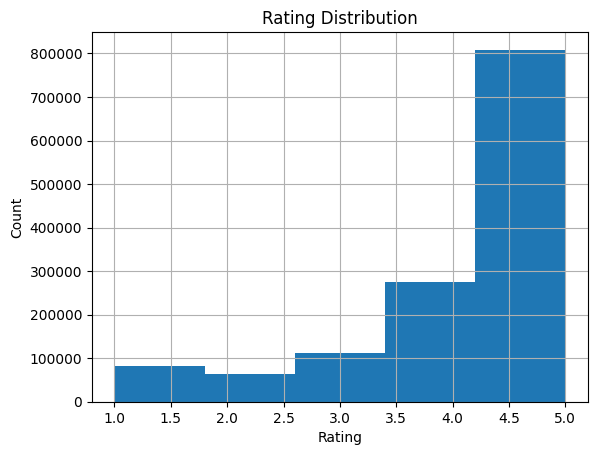

In [10]:
# Cell 3: Rating Distribution Histogram
df['rating'].hist(bins=5)
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.savefig("../data/eda/rating_distribution.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

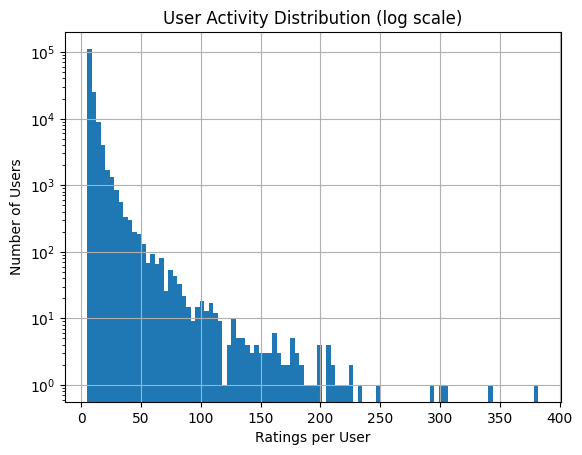

In [12]:
# Cell 4: User Activity Distribution (log scale)
user_activity = df.groupby('user_id').size()
user_activity.hist(bins=100, log=True)
plt.title("User Activity Distribution (log scale)")
plt.xlabel("Ratings per User")
plt.ylabel("Number of Users")
plt.savefig("../data/eda/user_activity_logscale.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

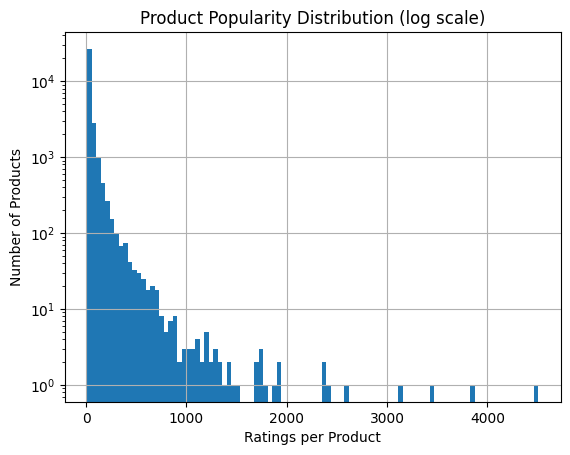

In [13]:
# Cell 5: Product Popularity Distribution (log scale)
product_activity = df.groupby('product_id').size()
product_activity.hist(bins=100, log=True)
plt.title("Product Popularity Distribution (log scale)")
plt.xlabel("Ratings per Product")
plt.ylabel("Number of Products")
plt.savefig("../data/eda/product_popularity_logscale.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()


In [14]:
# Cell 6: Matrix Density Calculation
n_users = df['user_id'].nunique()
n_products = df['product_id'].nunique()
n_interactions = len(df)
density = n_interactions / (n_users * n_products)

print(f"Users: {n_users}")
print(f"Products: {n_products}")
print(f"Interactions: {n_interactions}")
print(f"Matrix density: {density:.6f}")

Users: 155190
Products: 31785
Interactions: 1339071
Matrix density: 0.000271


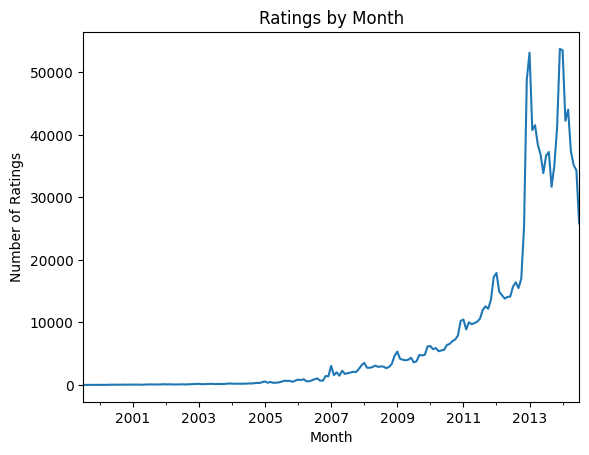

In [15]:
# Cell 7: Temporal Distribution of Ratings by Month
monthly_counts = df.groupby(df['timestamp'].dt.to_period("M")).size()
monthly_counts.plot(kind="line")
plt.title("Ratings by Month")
plt.xlabel("Month")
plt.ylabel("Number of Ratings")
plt.savefig("../data/eda/temporal_distribution.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()


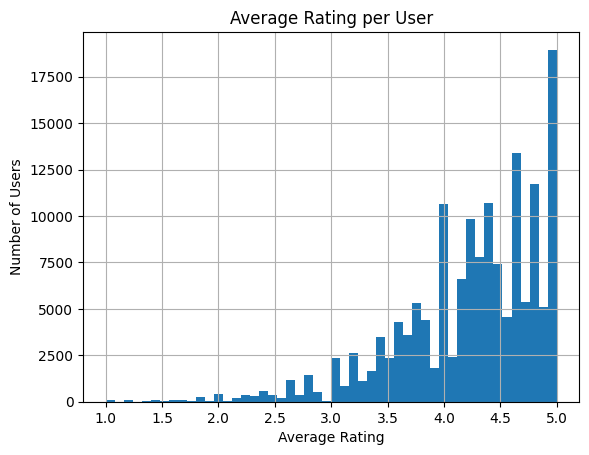

In [16]:
# Cell 8: Rating Distribution by User Segments (optional extra insight)
# Example: average rating per user
avg_user_rating = df.groupby('user_id')['rating'].mean()
avg_user_rating.hist(bins=50)
plt.title("Average Rating per User")
plt.xlabel("Average Rating")
plt.ylabel("Number of Users")
plt.savefig("../data/eda/avg_user_rating.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()